# Conférences Python Master TIDE #3

## A) Taux de change

On va s'intéresser au dataset des cours des devises de la Banque de France :
- https://webstat.banque-france.fr/fr/#/node/5385566

Les données sont dans le fichier `Webstat_Export.csv`.

L'idée est de charger les données, de les nettoyer et de pouvoir accéder aux cours de certaines devises à partir de leur code ISO3. On retiendra uniquement les colonnes se terminant effectivement par un code ISO3 entre parenthèses. Par ex., "Dollar des Etats-Unis (USD)".

1) Charger le fichier dans un DataFrame dont l'index doit correspondre aux dates, triées dans l'ordre chronologique et les colonnes doivent être les codes ISO3 des devises.

2) Sélectionner les devises : ['USD', 'CHF', 'GBP', 'JPY', 'TRY', 'CNY']

3) Calculer la moyenne des taux de change par année. Voir les codes de resampling : https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects

4) Faire des graphiques avec :
- Les taux de change divisés par leur moyenne.
- Les taux de change divisés par leur moyenne avec une moyenne glissante de 30 jours ou bien un maximum glissant de 100 jours.
- Les taux de change divisés par la dernière valeur connue avec une moyenne glissante de 30 jours.

5) Réindexer le DataFrame en prenant toutes les dates et compléter les valeurs manquantes par interpolation linéaire.

6) Avec la librairie **sparklines** afficher un DataFrame avec la moyenne annuelle des taux de change pour une monnaie donnée ainsi que la tendance par trimestre.

```python
import sparklines

print(sparklines.sparklines(pd.Series(range(8)))[0])
```

## B) Données télécom

Dataset des opérateurs télécom : `couverture-2g-3g-4g-en-france-par-operateur-juillet-2015.csv`

1) Chargez le fichier dans un DataFrame.

2) Transformez ce DataFrame large en un DataFrame long en isolant les colonnes d'identification d'une part et les colonnes de valeurs de couverture d'autre part.

3) Rajoutez 3 colonnes "Opérateur", "Type Couverture" et "Réseau" calculées à partir de la colonne "variable" obtenue en 2.

4) Chargez le DataFrame des communes déjà utilisé et effectuez une jointure sur le code INSEE.

6) Pour le réseau 4G et la couverture surfacique, calculez la moyenne des couvertures par statut de commune et par opérateur. Pour quel couple (statut, opérateur) a-t-on la moyenne de la couverture la plus faible ?

## C) Données RH

Dataset de StackOverflow : `survey_results_public_2022.zip`

1) Charger le fichier dans un DataFrame.

2) Sélectionner une colonne se terminant par "HaveWorkedWith" ou "WantToWorkWith" et la transformer en données numériques 0 ou 1 en utilisant la méthode `get_dummies()` de **pandas**.

3) Calculer un score en sommant les valeurs de chaque participant et afficher un diagramme de type box.

4) Considérer les colonnes "Age", "MainBranch" et "RemoteWork". En utilisant la classe `OneHotEncoder` de la librairie **scikit-learn** transformer ces colonnes en données numériques.

&copy; Francis Wolinski 2023

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# A-1/2

taux_change = pd.read_csv("data/Webstat_Export.csv",
                          sep=";",
                          na_values='-',
                          decimal=',',
                          skiprows=range(1,3))
header = pd.Series(taux_change.columns.to_list()).str.extract("\(([A-Z]{3})\)$", expand=False)
header[0] = "Date"
taux_change = taux_change.set_axis(header, axis=1)
taux_change["Date"] = pd.to_datetime(taux_change["Date"], format="%d/%m/%Y")
taux_change = taux_change.set_index("Date").sort_index()
taux_change = taux_change[['USD', 'CHF', 'GBP', 'JPY', 'TRY', 'CNY']]
taux_change = taux_change.dropna()
taux_change

,USD,CHF,GBP,JPY,TRY,CNY
Date,,,,,,
2000-01-13,1.0276,1.6111,0.62550,108.89,0.5555,8.5054
2000-01-14,1.0225,1.6130,0.62210,108.05,0.5536,8.4632
2000-01-17,1.0094,1.6136,0.61800,105.81,0.5523,8.3548
2000-01-18,1.0093,1.6131,0.61740,106.42,0.5521,8.3540
2000-01-19,1.0105,1.6120,0.61720,106.99,0.5523,8.3639
...,...,...,...,...,...,...
2023-01-30,1.0903,1.0045,0.87978,141.79,20.5063,7.3601
2023-01-31,1.0833,1.0032,0.88073,141.27,20.3787,7.3198
2023-02-01,1.0894,0.9980,0.88413,141.37,20.4978,7.3452


In [3]:
# A-3

taux_change.resample("A").mean()

,USD,CHF,GBP,JPY,TRY,CNY
Date,,,,,,
2000-12-31,0.920236,1.556258,0.608901,99.223036,0.575513,7.616797
2001-12-31,0.895630,1.510518,0.621874,108.682362,1.102425,7.413124
2002-12-31,0.945574,1.467025,0.628831,118.062549,1.439680,7.826513
2003-12-31,1.131160,1.521201,0.691993,130.971216,1.694852,9.362613
2004-12-31,1.243902,1.543822,0.678659,134.444595,1.777053,10.296699
2005-12-31,1.244090,1.548282,0.683796,136.849183,1.677079,10.195502
2006-12-31,1.255599,1.572878,0.681730,146.015333,1.808976,10.009558
2007-12-31,1.370478,1.642720,0.684337,161.252627,1.786484,10.417824
2008-12-31,1.470755,1.587395,0.796285,152.454062,1.906389,10.223613


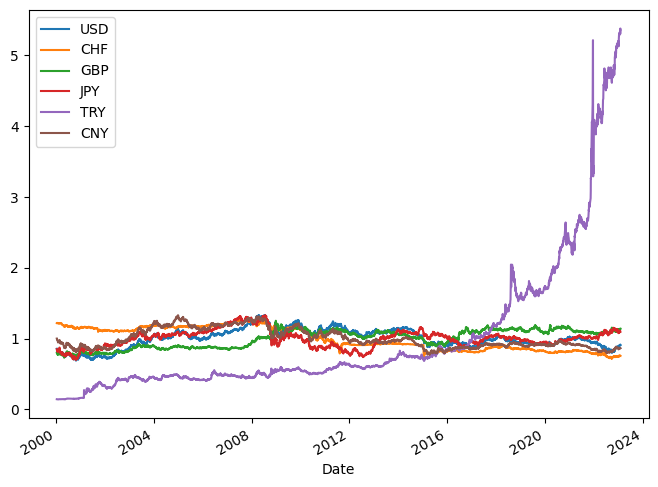

In [4]:
# A-4

fig, ax = plt.subplots(figsize=(8, 6))
(taux_change / taux_change.mean()).plot.line(ax=ax);

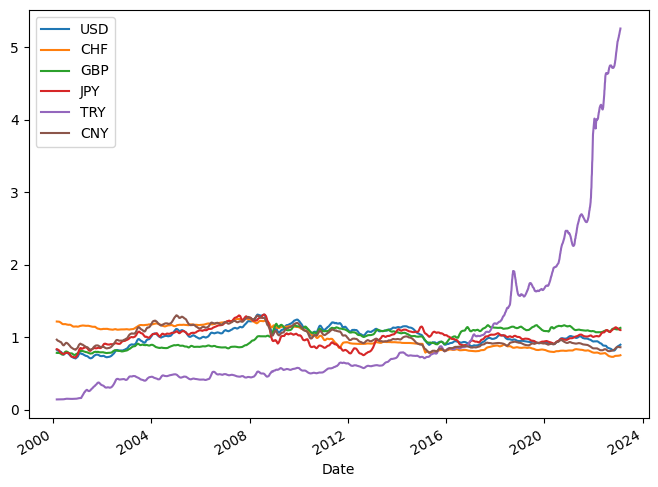

In [5]:
# A-4

fig, ax = plt.subplots(figsize=(8, 6))
(taux_change / taux_change.mean()).rolling(30).mean().plot.line(ax=ax);

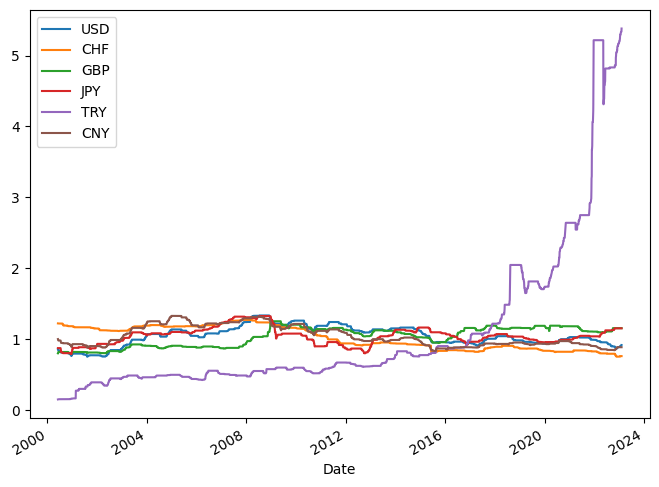

In [6]:
# A-4

fig, ax = plt.subplots(figsize=(8, 6))
(taux_change / taux_change.mean()).rolling(100).max().plot.line(ax=ax);

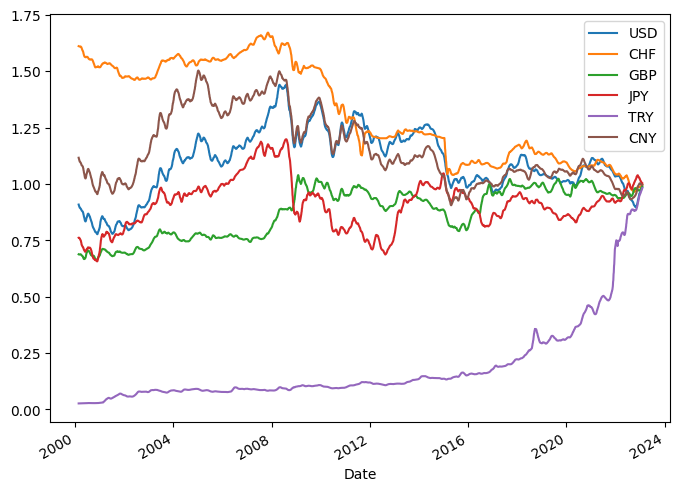

In [7]:
# A-4

fig, ax = plt.subplots(figsize=(8, 6))
(taux_change / taux_change.iloc[-1]).rolling(30).mean().plot.line(ax=ax);

In [8]:
# A-5

dates = pd.date_range(taux_change.index.min(), taux_change.index.max(), freq="D")
taux_change = taux_change.reindex(dates)
taux_change

,USD,CHF,GBP,JPY,TRY,CNY
2000-01-13,1.0276,1.6111,0.62550,108.89,0.5555,8.5054
2000-01-14,1.0225,1.6130,0.62210,108.05,0.5536,8.4632
2000-01-15,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-16,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-17,1.0094,1.6136,0.61800,105.81,0.5523,8.3548
...,...,...,...,...,...,...
2023-01-30,1.0903,1.0045,0.87978,141.79,20.5063,7.3601
2023-01-31,1.0833,1.0032,0.88073,141.27,20.3787,7.3198
2023-02-01,1.0894,0.9980,0.88413,141.37,20.4978,7.3452
2023-02-02,1.0988,0.9992,0.89289,141.12,20.6766,7.3878


In [9]:
# A-5

taux_change.interpolate()

,USD,CHF,GBP,JPY,TRY,CNY
2000-01-13,1.027600,1.6111,0.625500,108.890000,0.555500,8.505400
2000-01-14,1.022500,1.6130,0.622100,108.050000,0.553600,8.463200
2000-01-15,1.018133,1.6132,0.620733,107.303333,0.553167,8.427067
2000-01-16,1.013767,1.6134,0.619367,106.556667,0.552733,8.390933
2000-01-17,1.009400,1.6136,0.618000,105.810000,0.552300,8.354800
...,...,...,...,...,...,...
2023-01-30,1.090300,1.0045,0.879780,141.790000,20.506300,7.360100
2023-01-31,1.083300,1.0032,0.880730,141.270000,20.378700,7.319800
2023-02-01,1.089400,0.9980,0.884130,141.370000,20.497800,7.345200
2023-02-02,1.098800,0.9992,0.892890,141.120000,20.676600,7.387800


In [10]:
# A-5

pd.DataFrame(np.linspace(taux_change.iloc[1], taux_change.iloc[4], 4))

,0,1,2,3,4,5
0,1.022500,1.6130,0.622100,108.050000,0.553600,8.463200
1,1.018133,1.6132,0.620733,107.303333,0.553167,8.427067
2,1.013767,1.6134,0.619367,106.556667,0.552733,8.390933
3,1.009400,1.6136,0.618000,105.810000,0.552300,8.354800


In [14]:
import sparklines

print(sparklines.sparklines(pd.Series(range(8)))[0])

▁▂▃▄▅▆▇█


In [15]:
# A-6
taux_change.resample("A").agg(moyenne=('TRY', lambda s: s.mean().round(3)),
                              tendance=('TRY', lambda s: sparklines.sparklines(s.resample('Q').mean())[0]))

,moyenne,tendance
2000-12-31,0.576,▁▄▇█
2001-12-31,1.102,▁▄▇█
2002-12-31,1.440,▁▃██
2003-12-31,1.695,█▆▁▆
2004-12-31,1.777,▁▄▆█
2005-12-31,1.677,█▇▂▁
2006-12-31,1.809,▁▇█▇
2007-12-31,1.786,█▅▃▁
2008-12-31,1.906,▁▆▂█
2009-12-31,2.163,▄▁▁█


In [16]:
# B-1
telco = pd.read_csv("data/couverture-2g-3g-4g-en-france-par-operateur-juillet-2015.csv",
                    sep=";")
telco

,CODE POSTAL,CODE INSEE,NOM COMMUNE,CODE DEPARTEMENT,SURFACE COMMUNE (km²),POPULATION COMMUNE,Orange France Couverture population 4G,Bouygues Telecom Couverture population 4G,SFR Couverture population 4G,Free Mobile Couverture population 4G,...,Bouygues Telecom Couverture population 2G,SFR Couverture population 2G,Free Mobile Couverture population 2G,Par au moins un opérateur Couverture population 2G,Orange France Couverture surfacique 2G,Bouygues Telecom Couverture surfacique 2G,SFR Couverture surfacique 2G,Free Mobile Couverture surfacique 2G,Par au moins un opérateur Couverture surfacique 2G,coordonnees
0,17510,17105,CHIVES,17,20.642005,355.32,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,0.99,1.00,1.00,1.0,"45.9508835378, -0.121918052323"
1,17600,17112,LA CLISSE,17,4.896771,591.78,0.09,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"45.7320429784, -0.75493581331"
2,17150,17116,CONSAC,17,8.915911,239.74,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"45.4182495786, -0.588917528415"
3,17130,17118,CORIGNAC,17,10.850210,358.69,0.00,0.00,0.00,0.0,...,0.63,1.0,1.0,1.0,0.99,0.85,1.00,0.99,1.0,"45.2448604983, -0.39280322021"
4,17330,17124,COURANT,17,15.586269,371.00,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"46.0375312829, -0.587834905531"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36589,70000,70378,NAVENNE,70,3.826265,1847.69,1.00,1.00,0.99,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"47.6030208472, 6.1618556725"
36590,70000,70388,NOIDANS-LES-VESOUL,70,8.634594,2159.19,0.99,0.95,0.36,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"47.6097514089, 6.11842989879"
36591,70100,70389,NOIRON,70,5.768295,64.01,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,0.98,0.96,1.00,1.0,"47.3828510502, 5.62597938451"
36592,70500,70399,ORMOY,70,19.577164,224.76,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,0.99,0.98,1.00,1.0,"47.8850612988, 5.99402771513"


In [17]:
# B-2

id_vars = telco.columns[:6].tolist()+[telco.columns[-1]]
telco_long = telco.melt(id_vars=id_vars)
telco_long

,CODE POSTAL,CODE INSEE,NOM COMMUNE,CODE DEPARTEMENT,SURFACE COMMUNE (km²),POPULATION COMMUNE,coordonnees,variable,value
0,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Orange France Couverture population 4G,0.00
1,17600,17112,LA CLISSE,17,4.896771,591.78,"45.7320429784, -0.75493581331",Orange France Couverture population 4G,0.09
2,17150,17116,CONSAC,17,8.915911,239.74,"45.4182495786, -0.588917528415",Orange France Couverture population 4G,0.00
3,17130,17118,CORIGNAC,17,10.850210,358.69,"45.2448604983, -0.39280322021",Orange France Couverture population 4G,0.00
4,17330,17124,COURANT,17,15.586269,371.00,"46.0375312829, -0.587834905531",Orange France Couverture population 4G,0.00
...,...,...,...,...,...,...,...,...,...
1097815,70000,70378,NAVENNE,70,3.826265,1847.69,"47.6030208472, 6.1618556725",Par au moins un opérateur Couverture surfaciqu...,1.00
1097816,70000,70388,NOIDANS-LES-VESOUL,70,8.634594,2159.19,"47.6097514089, 6.11842989879",Par au moins un opérateur Couverture surfaciqu...,1.00
1097817,70100,70389,NOIRON,70,5.768295,64.01,"47.3828510502, 5.62597938451",Par au moins un opérateur Couverture surfaciqu...,1.00
1097818,70500,70399,ORMOY,70,19.577164,224.76,"47.8850612988, 5.99402771513",Par au moins un opérateur Couverture surfaciqu...,1.00


In [18]:
# B-3

telco_long[["Opérateur", "Couverture", "Techno"]] = telco_long["variable"].str.extract("(.+) (Couverture [a-z]+) ([2-4]G)$")
telco_long

,CODE POSTAL,CODE INSEE,NOM COMMUNE,CODE DEPARTEMENT,SURFACE COMMUNE (km²),POPULATION COMMUNE,coordonnees,variable,value,Opérateur,Couverture,Techno
0,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Orange France Couverture population 4G,0.00,Orange France,Couverture population,4G
1,17600,17112,LA CLISSE,17,4.896771,591.78,"45.7320429784, -0.75493581331",Orange France Couverture population 4G,0.09,Orange France,Couverture population,4G
2,17150,17116,CONSAC,17,8.915911,239.74,"45.4182495786, -0.588917528415",Orange France Couverture population 4G,0.00,Orange France,Couverture population,4G
3,17130,17118,CORIGNAC,17,10.850210,358.69,"45.2448604983, -0.39280322021",Orange France Couverture population 4G,0.00,Orange France,Couverture population,4G
4,17330,17124,COURANT,17,15.586269,371.00,"46.0375312829, -0.587834905531",Orange France Couverture population 4G,0.00,Orange France,Couverture population,4G
...,...,...,...,...,...,...,...,...,...,...,...,...
1097815,70000,70378,NAVENNE,70,3.826265,1847.69,"47.6030208472, 6.1618556725",Par au moins un opérateur Couverture surfaciqu...,1.00,Par au moins un opérateur,Couverture surfacique,2G
1097816,70000,70388,NOIDANS-LES-VESOUL,70,8.634594,2159.19,"47.6097514089, 6.11842989879",Par au moins un opérateur Couverture surfaciqu...,1.00,Par au moins un opérateur,Couverture surfacique,2G
1097817,70100,70389,NOIRON,70,5.768295,64.01,"47.3828510502, 5.62597938451",Par au moins un opérateur Couverture surfaciqu...,1.00,Par au moins un opérateur,Couverture surfacique,2G
1097818,70500,70399,ORMOY,70,19.577164,224.76,"47.8850612988, 5.99402771513",Par au moins un opérateur Couverture surfaciqu...,1.00,Par au moins un opérateur,Couverture surfacique,2G


In [19]:
# B-4

geo = pd.read_csv("data/correspondance-code-insee-code-postal.csv", sep=";", usecols=range(11))

statut_dtype = pd.CategoricalDtype(categories=["Commune simple", "Chef-lieu canton", "Sous-préfecture",
                                               "Préfecture", "Préfecture de région", "Capitale d'état"], 
                                   ordered=True)
geo["Statut"] = geo["Statut"].astype(statut_dtype)

df = pd.merge(telco_long, geo, left_on = "CODE INSEE", right_on="Code INSEE")
df.head()

,CODE POSTAL,CODE INSEE,NOM COMMUNE,CODE DEPARTEMENT,SURFACE COMMUNE (km²),POPULATION COMMUNE,coordonnees,variable,value,Opérateur,...,Code Postal,Commune,Département,Région,Statut,Altitude Moyenne,Superficie,Population,geo_point_2d,geo_shape
0,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Orange France Couverture population 4G,0.0,Orange France,...,17510,CHIVES,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,108.0,2062.0,0.4,"45.9508835378, -0.121918052323","{""type"": ""Polygon"", ""coordinates"": [[[-0.10484..."
1,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Bouygues Telecom Couverture population 4G,0.0,Bouygues Telecom,...,17510,CHIVES,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,108.0,2062.0,0.4,"45.9508835378, -0.121918052323","{""type"": ""Polygon"", ""coordinates"": [[[-0.10484..."
2,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",SFR Couverture population 4G,0.0,SFR,...,17510,CHIVES,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,108.0,2062.0,0.4,"45.9508835378, -0.121918052323","{""type"": ""Polygon"", ""coordinates"": [[[-0.10484..."
3,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Free Mobile Couverture population 4G,0.0,Free Mobile,...,17510,CHIVES,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,108.0,2062.0,0.4,"45.9508835378, -0.121918052323","{""type"": ""Polygon"", ""coordinates"": [[[-0.10484..."
4,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Par au moins un opérateur Couverture populatio...,0.0,Par au moins un opérateur,...,17510,CHIVES,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,108.0,2062.0,0.4,"45.9508835378, -0.121918052323","{""type"": ""Polygon"", ""coordinates"": [[[-0.10484..."


In [20]:
# B-5

tab = df.pivot_table(index="Statut",
                     columns="Opérateur",
                     values="value")
tab

Opérateur,Bouygues Telecom,Free Mobile,Orange France,Par au moins un opérateur,SFR
Statut,,,,,
Commune simple,0.674952,0.618844,0.722571,0.775593,0.688295
Chef-lieu canton,0.738376,0.665798,0.765599,0.812451,0.732112
Sous-préfecture,0.813506,0.706508,0.880260,0.900844,0.778167
Préfecture,0.923131,0.796982,0.978333,0.985901,0.890113
Préfecture de région,0.985556,0.895794,0.983095,0.993571,0.974365
Capitale d'état,0.998333,0.990000,1.000000,1.000000,1.000000


In [21]:
# B-5

(tab.stack()==tab.min().min()).idxmax()

('Commune simple', 'Free Mobile')

In [22]:
# C-1

survey = pd.read_csv("data/survey_results_public_2022.zip")
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

In [23]:
# C-2

survey["LanguageHaveWorkedWith"].str.get_dummies(";")

,APL,Assembly,Bash/Shell,C,C#,C++,COBOL,Clojure,Crystal,Dart,...,R,Ruby,Rust,SAS,SQL,Scala,Solidity,Swift,TypeScript,VBA
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73263,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
73264,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
73265,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
73266,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


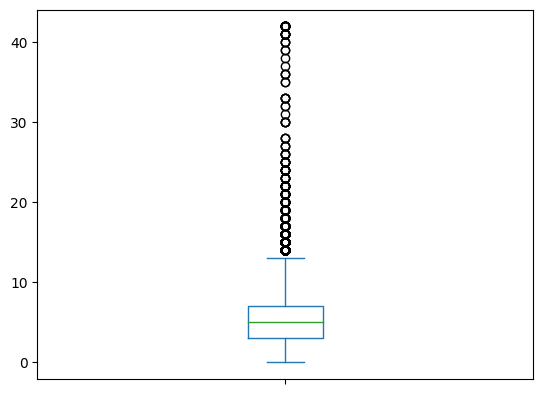

In [24]:
# C-3
survey["LanguageHaveWorkedWith"].str.get_dummies(";").sum(axis=1).plot.box();

In [25]:
# C-4

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
tab = pd.DataFrame(encoder.fit_transform(survey[["Age", "MainBranch", "RemoteWork"]]).toarray(),
                   columns=encoder.get_feature_names_out())
tab

,Age_18-24 years old,Age_25-34 years old,Age_35-44 years old,Age_45-54 years old,Age_55-64 years old,Age_65 years or older,Age_Prefer not to say,Age_Under 18 years old,Age_nan,MainBranch_I am a developer by profession,MainBranch_I am learning to code,"MainBranch_I am not primarily a developer, but I write code sometimes as part of my work",MainBranch_I code primarily as a hobby,"MainBranch_I used to be a developer by profession, but no longer am",MainBranch_None of these,RemoteWork_Full in-person,RemoteWork_Fully remote,"RemoteWork_Hybrid (some remote, some in-person)",RemoteWork_nan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73263,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
73264,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
73265,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
73266,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
